## Plotly and cufflinks : Advanced Python Data Visualization Libraries
Generally, we are taught about only these two libraries matplotlib and seaborn. These libraries provide features using which we can draw line charts, pie charts, bar plots, box plots, and many more plots. Now, you must have a question if we already have matplotlib and seaborn, then why we need other libraries for data visualization? This is the same question that arrived in my mind when I first heard about plotly and cufflinks. However, when I read about them and used them in my projects then it had completely blown my mind, the power these libraries provide in your hand is amazing.

Plotly is an open-source and charting library that provides the facility of interactive plotting. The library is available for several programming languages such as Python, R, MATLAB, Arduino, and REST, among others.

Cufflink is also a python library that connects plotly with pandas so that we can create charts directly on data frames. It basically acts as a plugin.

Plotly charts are dynamic in nature, it allows us to hover over the values, zoom in zoom out of graphs, identifies outliers in the dataset. On the other hand, matplotlib and seaborn charts are static, we can’t zoom in or zoom-out, it does not provide detail of every value on the chart. The most important feature of plotly is that it allows us to build dynamic charts for the web directly from python which is not possible in the case of matplotlib. With plotly, we can also create animations and interactive graphs on geographical, scientific, statistical, and financial data.

First, we install these two libraries using the pip command.

pip install plotly
pip install cufflinks

After installing, we import all necessary modules in our python shell or jupyter notebook.

The datetime module supplies classes for manipulating dates and times.

In [2]:
import pandas as pd
import numpy as np
import plotly
import datetime
from datetime import date
import cufflinks as cf

For enabling the offline mode for plotting locally in the jupyter notebook we write the below code.

In [5]:
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

download_plotlyjs is a parameter used in Plotly's Python library when exporting visualizations to HTML. It controls how the Plotly JavaScript (plotly.js) library is included in the exported HTML file.

init_notebook_mode is a function in Plotly’s Python library, used when working in Jupyter Notebooks. It initializes Plotly for rendering interactive plots directly inside a Jupyter Notebook. If you're working in a Jupyter Notebook and want to display Plotly figures interactively. Without this initialization, iplot() may not display interactive plots properly.

The key difference between plot and iplot in plotly.offline is how they display Plotly figures, particularly in Jupyter Notebooks.

1. plot()
Generates an HTML file containing the plot and opens it in a new browser tab (or saves it).
Can be used outside of Jupyter Notebooks.

2. iplot()
Displays the plot directly inside a Jupyter Notebook cell.
Requires init_notebook_mode(connected=True) to be called beforehand.

If you're working in a Jupyter Notebook, use iplot() for inline display. If you want to generate a standalone HTML file, use plot().

In [8]:
# Initialize Plotly to work in offline mode inside Jupyter Notebook
# connected=True: Downloads and uses plotly.js directly from the web (CDN).
# connected=False: Uses a locally installed version of plotly.js.
init_notebook_mode(connected=True)

In [10]:
cf.go_offline()

cf.go_offline() is a function in Cufflinks, a Python library that connects Pandas with Plotly to create interactive visualizations easily.

Purpose:
It enables offline mode for Plotly, allowing interactive plots to be displayed directly in Jupyter Notebooks without requiring an internet connection.
Works with iplot() to show plots inline.

Key Features:
Works inside Jupyter Notebooks.
No need to call init_notebook_mode(connected=True).
Allows using iplot() with Pandas DataFrames.

Dataset
Before going for the implementation of plotly, we first need to understand our dataset and operations that can be applied to do data visualization using various charts.

We have taken the tata motors shares price dataset of 6 years period(2016-2021) from yahoo finance. The dataset has 7 columns that include the date, close price, open price, high, low, adj close, and volume. Then we have added two columns i.e. year and month in the dataset which will help in plotting the charts. The following code is written below:

In [14]:
stock_data=pd.read_csv('Tata_Motors_Ltd._historical_data.csv')
stock_data['Year']=pd.DatetimeIndex(stock_data['Date']).year
stock_data['Month']=pd.DatetimeIndex(stock_data['Date']).month
stock_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month
0,2000-01-03,43.5,43.5,43.5,43.5,16.114737,0,2000,1
1,2000-01-04,43.5,43.5,43.5,43.5,16.114737,0,2000,1
2,2000-01-05,43.5,43.5,43.5,43.5,16.114737,0,2000,1
3,2000-01-06,43.5,43.5,43.5,43.5,16.114737,0,2000,1
4,2000-01-07,43.5,43.5,43.5,43.5,16.114737,0,2000,1


In [16]:
stock_data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month
5881,2023-08-28,606.299988,608.400024,601.549988,602.200012,602.200012,1317553,2023,8
5882,2023-08-29,604.900024,610.549988,603.000000,606.549988,606.549988,524651,2023,8
5883,2023-08-30,611.200012,613.000000,604.799988,605.549988,605.549988,523411,2023,8
5884,2023-08-31,608.049988,609.650024,599.099976,601.099976,601.099976,1242644,2023,8
5885,2023-09-01,603.549988,614.799988,601.650024,611.200012,611.200012,1454215,2023,9


Date: The specific trading day for the recorded prices.

Open: The stock price at the beginning of the trading session.

High: The highest price reached during the trading session.

Low: The lowest price reached during the trading session.

Close: The stock price at the end of the trading session.

Adj Close (Adjusted Close): The closing price adjusted for stock splits, dividends, and other corporate actions. This is useful for historical comparisons.

Volume: The total number of shares traded on that day.

Additional Derived Columns:

Year: The year extracted from the "Date" column (useful for filtering or grouping data).

Month: The month extracted from the "Date" column (useful for trend analysis).

## Basic Charts
Now, we will draw several charts on this dataset.

lotly.express is a high-level module in Plotly designed for creating interactive visualizations quickly with minimal code. It simplifies data visualization by providing concise functions that automatically handle figure creation, axes, legends, and themes.

Key Features:
✅ Concise Syntax – Requires fewer lines of code than plotly.graph_objects
✅ Built-in Data Handling – Works seamlessly with Pandas DataFrames
✅ Automatic Styling – Applies default themes and layout configurations
✅ Supports Various Chart Types – Scatter, line, bar, box, violin, pie, and more.

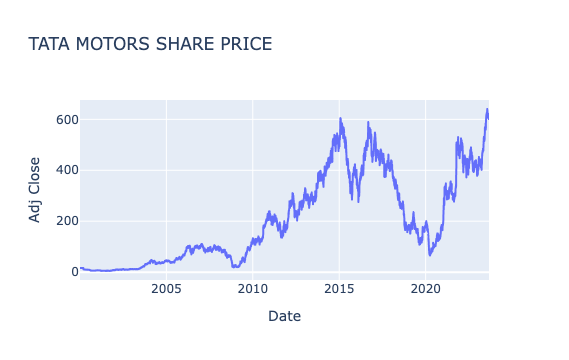

In [20]:
# Line chart
import plotly.express as px
fig = px.line(stock_data, x="Date", y="Adj Close",title = 'TATA MOTORS SHARE PRICE')
fig.show()

As we can see above, Plotly provides a set of options to play around with the visualization. On the top right corner of the plot, you can see like 8 to 10 buttons that offer several functionalities. In the order of buttons from going left to right, we have one to download the plot as a png image, toggle buttons to switch between zoom mode and pan mode, a zoom in and zoom out button, and an autoscale button to reset the scale in the plot, a reset axis button, a button to toggle the spike lines in the graph, and pair of toggle button to switch between different mouse hover modes.

This line chart shows the tata motors share price. We can zoom in for a particular year and a month and can see the share price of each day by hovering on it.

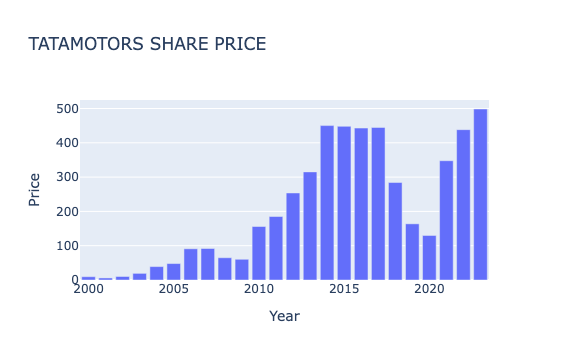

In [23]:
# Bar plot
# This bar plot shows the mean share price of tata motors in several years.
stock=stock_data.groupby('Year')['Adj Close'].mean()
fig = px.bar(stock, x=stock.index, y=stock.values,title = 'TATAMOTORS SHARE PRICE',
             labels={'y':'Price'})
fig.show()

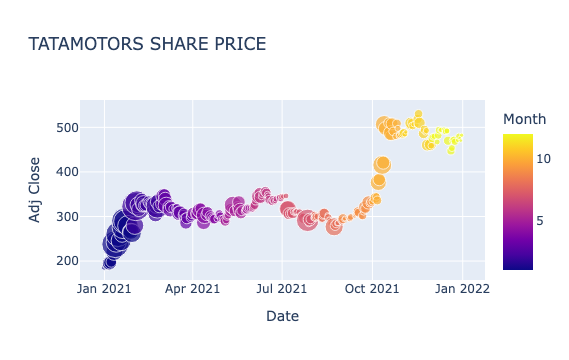

In [25]:
# ASK THIS:
# Bubble chart
# This bubble chart shows the tata motors share price across different months in the year 2021
# and the size of the bubble represents the volume of shares traded.
df=stock_data.loc[stock_data['Year']==2021,['Date','Adj Close','Volume','Year','Month']]
fig = px.scatter(df, x="Date", y="Adj Close",
         size='Volume',color='Month',title = 'TATAMOTORS SHARE PRICE')
fig.show()

### Statistical Charts

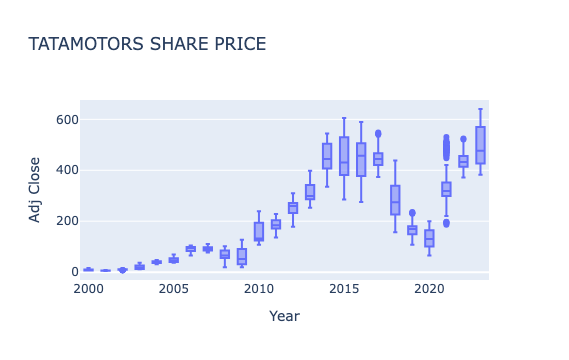

In [28]:
# Box Plot
fig = px.box(stock_data, x="Year", y="Adj Close",title = 'TATAMOTORS SHARE PRICE')
fig.show()

This box plot gives the various descriptive stats of the share price of tata motors for different years. It provides the max, min, median, quantile 1, quantile 3, and max/min values excluding outlier.

REMINDER:
In stock charts, particularly in candlestick and box plots, the lines extending from the top and bottom of the boxes or candles are called "wicks" or "shadows."

Terminology:
Upper Wick/Shadow: The line extending above the box/candle represents the highest price reached during the time period.
Lower Wick/Shadow: The line extending below the box/candle represents the lowest price reached during the time period.
Body (Box part): Represents the range between the opening and closing prices.
In Different Chart Types:
Candlestick Chart:

Wicks indicate the high and low prices for the period.
The box (candle body) shows the difference between opening and closing prices.
If the close is higher than the open, the candle is typically green (bullish).
If the close is lower than the open, the candle is typically red (bearish).
Box Plot (for stock volatility analysis):

The box represents the interquartile range (IQR) of stock prices.
The whiskers (lines extending from the box) show the minimum and maximum values.

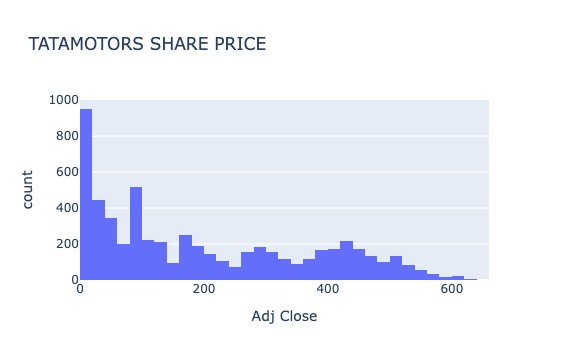

In [31]:
# Histogram
fig = px.histogram(stock_data, x="Adj Close",title = 'TATAMOTORS SHARE PRICE')
fig.show()

The histogram tells us about the count of the share price of tata motors over 25 years. We can that for most of the period the share price was between 160 and 200.

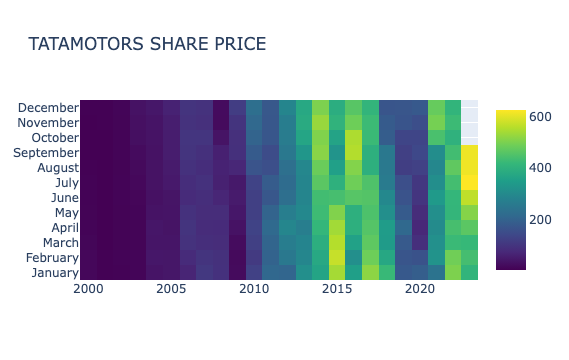

In [34]:
# Heatmap
dff= stock_data[['Adj Close','Year','Month']]
dff=dff.groupby(['Year','Month']).mean()
dff=dff.unstack(level=0)
dff.head()
month=['January','February','March','April','May','June','July','August','September',
       'October','November','December']
year = [] 
for num in range(2000, 2024):
    year.append(num) 
import plotly.graph_objects as go
fig = go.Figure(data=go.Heatmap(
        z=dff,
        x=year,
        y=month,
        colorscale='Viridis'))
fig.update_layout(title="TATAMOTORS SHARE PRICE")
fig.show()

The heatmap shows the share price of tata motors across months and their respective years. By hovering we can get details of each block.

Candlestick chart gives the open, close, high, and low price of each day. There is also a slidebar under the chart that we can use to get the chart for any range.

Area Chart gives the area under the stock price. It is useful to see the trend and variation in share price over the years.

Plotly also provides scientific charts, 3-D charts, maps, and animations. You can visit plotly documentation here for more details:

https://plotly.com/python/

### # Another example for financial plotting
The combination of plotly, Cufflinks, and pandas proves particularly powerful when working with financial time series data. Cufflinks provides specialized functionality to create typical financial plots and to add typical financial charting elements, such as the Relative Strength Index (RSI), to name but one example. To this end, a persistent QuantFig object is created that can be plotted the same way as a DataFrame object with Cufflinks.
This subsection uses a real financial data set, time series data for the EUR/USD exchange rate (source: FXCM Forex Capital Markets Ltd.):

In [41]:
# data from FXCM Forex Capital Markets Ltd.
raw = pd.read_csv('http://hilpisch.com/fxcm_eur_usd_eod_data.csv',
                 index_col=0, parse_dates=True)

In [42]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1547 entries, 2013-01-01 22:00:00 to 2017-12-31 22:00:00
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BidOpen   1547 non-null   float64
 1   BidHigh   1547 non-null   float64
 2   BidLow    1547 non-null   float64
 3   BidClose  1547 non-null   float64
 4   AskOpen   1547 non-null   float64
 5   AskHigh   1547 non-null   float64
 6   AskLow    1547 non-null   float64
 7   AskClose  1547 non-null   float64
dtypes: float64(8)
memory usage: 108.8 KB


In [45]:
quotes = raw[['AskOpen', 'AskHigh', 'AskLow', 'AskClose']]
# Only a few data rows are used for the visualization.
quotes = quotes.iloc[-60:]
quotes.tail()

,AskOpen,AskHigh,AskLow,AskClose
2017-12-25 22:00:00,1.18667,1.18791,1.18467,1.18587
2017-12-26 22:00:00,1.18587,1.19104,1.18552,1.18885
2017-12-27 22:00:00,1.18885,1.19592,1.18885,1.19426
2017-12-28 22:00:00,1.19426,1.20256,1.19369,1.20092
2017-12-31 22:00:00,1.20092,1.20144,1.19994,1.20144


In [47]:
quotes.head()

,AskOpen,AskHigh,AskLow,AskClose
2017-10-19 21:00:00,1.18539,1.18581,1.17625,1.17822
2017-10-21 21:00:00,1.17822,1.17822,1.17597,1.17655
2017-10-22 21:00:00,1.17655,1.17774,1.17248,1.17495
2017-10-23 21:00:00,1.17495,1.17930,1.17429,1.17622
2017-10-24 21:00:00,1.17622,1.18178,1.17532,1.18132


Cufflinks' QuantFig is a powerful tool for visualizing financial and stock market data, built on top of Plotly.

QuantFig stands for "Quantitative Figure", which is a specialized visualization object in Cufflinks designed for quantitative financial analysis.

It helps in technical analysis by generating interactive stock charts with built-in support for:

Candlestick & OHLC charts

Moving Averages (SMA, EMA)

Bollinger Bands (BB)

Relative Strength Index (RSI)

MACD (Moving Average Convergence Divergence)

Trading Volume Data

It's a powerful tool for traders and analysts who need quick, interactive, and visually appealing stock market insights using Plotly and Pandas.

To use QuantFig, you need to have Pandas, Cufflinks, and Plotly installed. If not, install them first.

!!! Bollinger Bands are a popular technical analysis tool used to measure market volatility and identify potential overbought or oversold conditions. They consist of three lines:

Upper Band – Indicates the highest expected price range.

Middle Band (SMA - Simple Moving Average) – Represents the average price over a given period.

Lower Band – Indicates the lowest expected price range.

These bands expand when the market is volatile and contract when the market is stable.

Formula for Bollinger Bands.
The bands are calculated as follows:

Middle Band = Simple Moving Average (SMA) of price (usually 20 periods)

Upper Band = SMA + (Standard Deviation × Multiplier)

Lower Band = SMA - (Standard Deviation × Multiplier)

The default multiplier is 2, meaning the bands are two standard deviations away from the SMA.

How to Interpret Bollinger Bands?

Price Near the Upper Band → Market is overbought (potential selling opportunity).

Price Near the Lower Band → Market is oversold (potential buying opportunity).

Bands Expanding → High volatility (strong price movement expected).

Bands Contracting → Low volatility (possible breakout soon).

!!! RSI (Relative Strength Index) is a momentum indicator in technical analysis that measures the speed and change of price movements. It helps traders determine whether a stock is overbought or oversold by comparing recent gains and losses over a specific period (typically 14 days).

RSI = 100-(100/(1+RS))

Where:

RS (Relative Strength) = Average Gain / Average Loss over the period (default is 14).
RSI values range from 0 to 100.

How to Interpret RSI?

RSI > 70 → Overbought (Stock may be overvalued, potential for price drop or correction).

RSI < 30 → Oversold (Stock may be undervalued, potential for price rebound).

RSI Between 30-70 → Neutral zone (No strong trend).

Divergences:

Bullish Divergence: When RSI is increasing, but the stock price is decreasing → Possible buy signal.

Bearish Divergence: When RSI is decreasing, but the stock price is increasing → Possible sell signal.


During instantiation, the QuantFig object takes the DataFrame object as input and allows for some basic customization. Plotting the data stored in the QuantFig object qf then happens with the qf.iplot() method.

In [51]:
qf = cf.QuantFig(
         quotes,
         title='EUR/USD Exchange Rate',
         legend='top',
         name='EUR/USD'
)

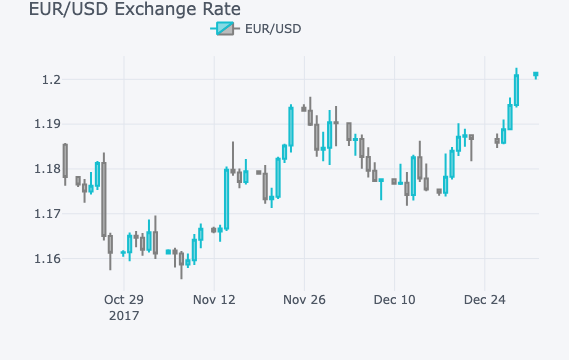

In [53]:
qf.iplot()

Adding typical financial charting elements, such as Bollinger bands, is possible via different methods available for the QuantFig object.

In [56]:
# parameters:
# The number of periods for the Bollinger band.
# The number of standard deviations to be used for the bandwidth.
qf.add_bollinger_bands(periods=15,
                       boll_std=2)

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



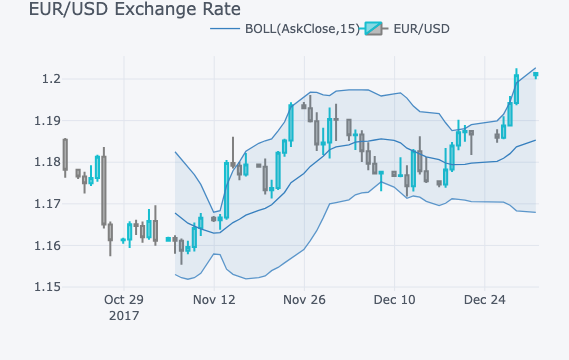

In [58]:
qf.iplot()

In [60]:
# Certain financial indicators, such as RSI, may be added as a subplot
# False -> Does not show an upper or lower band.
qf.add_rsi(periods=14,
          showbands=False)

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

/opt/anaconda3/lib/python3.12/site-packages/cufflinks/plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



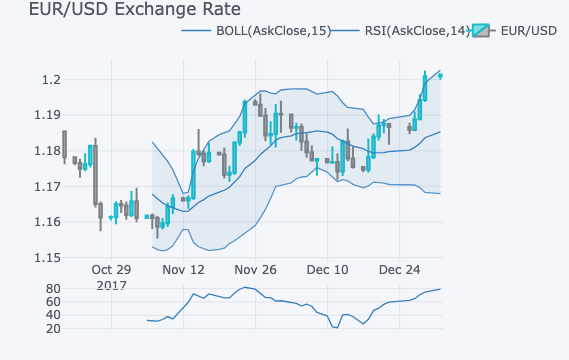

In [62]:
qf.iplot()